<a href="https://colab.research.google.com/github/14marcos1/ELT579/blob/main/ELT_NLP_P2_MARCOS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center>Universidade Federal de Viçosa</center>
<center>Coordenadoria de Educação Aberta e a Distância</center>
<center>Inteligência Artificial e Computacional</center>
<center>ELT579 - Topicos Especiais em Inteligencia Artificial</center>

**<center>AULA PRÁTICA 2: Modelo Transformer no PyTorch usando TorchText</center>**

_<center>Processamento de Linguagem Natural</center>_

**Objetivo:** Nesta prática, vamos construir um modelo Transformer para processamento de texto usando o PyTorch e TorchText. Vamos seguir as etapas de pré-processamento dos dados, tokenização, criação do vocabulário, construção do modelo, e por fim, testá-lo com um conjunto de dados.

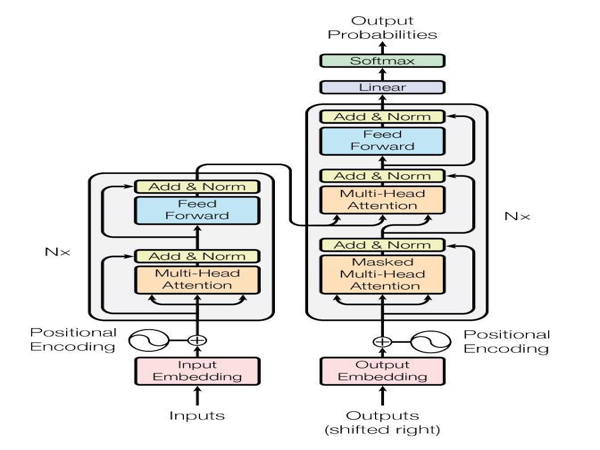

In [ ]:
from IPython.display import Image, display
from PIL import Image as PILImage
import requests
from io import BytesIO

# URL da imagem
url = "https://github.com/pytorch/tutorials/blob/gh-pages/_static/img/transformer_architecture.jpg?raw=1"

# Requisição da imagem da web
response = requests.get(url)
img = PILImage.open(BytesIO(response.content))

# Redimensionar a imagem (ajuste os valores conforme necessário)
img_resized = img.resize((600, 450))  # Define a largura e altura (em pixels)

# Exibir a imagem redimensionada
display(img_resized)

In [ ]:
!pip uninstall -y torch torchtext
!pip install torch==2.0.0 torchtext==0.15.1

ERROR: Could not find a version that satisfies the requirement torch==2.0.0 (from versions: 2.2.0, 2.2.1, 2.2.2, 2.3.0, 2.3.1, 2.4.0, 2.4.1, 2.5.0, 2.5.1, 2.6.0, 2.7.0, 2.7.1, 2.8.0, 2.9.0, 2.9.1, 2.10.0, 2.11.0)
ERROR: No matching distribution found for torch==2.0.0


**1. Montagem do Google Drive**

Para começar, montamos o Google Drive para acessar arquivos diretamente do Colab:

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**2. Definir constantes e o tokenizador**

`MAX_LENGTH`: define o comprimento máximo das sequências de texto.

`tokenizer`: usamos o tokenizador básico em inglês do `torchtext` para separar o texto em palavras.

In [2]:
import torchtext
from torchtext.data.utils import get_tokenizer
MAX_LENGTH = 100 ############################
tokenizer = get_tokenizer('basic_english')

ModuleNotFoundError: No module named 'torchtext'

**3.   Função para carregar e amostrar os dados**

A amostragem é útil para reduzir o tempo de processamento e uso de memória ao trabalhar com grandes conjuntos de dados.

In [3]:
#Caminho dos arquivos de treino, validação e teste no Google Drive.
import os

folder = '/content/drive/MyDrive/ELT579/SEMANA_4/wikitext-2'
train_file = os.path.join(folder, 'wiki.train.tokens')
val_file = os.path.join(folder, 'wiki.valid.tokens')
test_file = os.path.join(folder, 'wiki.test.tokens')

#Função para carregar e amostrar os dados:
def load_and_sample(file_path, fraction=0.1):
    with open(file_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()
    num_lines = int(len(lines) * fraction)
    sampled_lines = lines[:num_lines]
    return sampled_lines

#Carregar e amostrar dados:
#Carregue 10% dos dados de treino, validação e teste.
train_sample = load_and_sample(train_file, fraction=0.1)
val_sample = load_and_sample(val_file, fraction=0.1)
test_sample = load_and_sample(test_file, fraction=0.1)


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/ELT579/SEMANA_4/wikitext-2/wiki.train.tokens'

**4. Tokenização e Padronização de Sequências**

Aqui, as sequências são truncadas ou preenchidas para garantir que todas tenham o mesmo tamanho:

In [ ]:
#Função para truncar ou preencher sequências
#Trunca as sequências que são maiores que MAX_LENGTH e preenche aquelas que são menores com o token <pad>.
def truncate_or_pad(tokens, max_length):
    if len(tokens) > max_length:
        return tokens[:max_length]
    else:
        return tokens + ['<pad>'] * (max_length - len(tokens))

#PRE-PROCESSAMENTO (AULA PRATICA 1)

#Tokenizar e ajustar sequências
#Tokeniza as amostras e ajusta-as ao comprimento máximo definido.
train_tokens = [truncate_or_pad(tokenizer(line), MAX_LENGTH) for line in train_sample]
val_tokens = [truncate_or_pad(tokenizer(line), MAX_LENGTH) for line in val_sample]
test_tokens = [truncate_or_pad(tokenizer(line), MAX_LENGTH) for line in test_sample]

#Definir tokens especiais
#Tokens como <unk>, <sos>, <eos> e <pad> são adicionados para representar palavras desconhecidas, início/fim de frase e preenchimento, respectivamente.
specials = ['<unk>', '<sos>', '<eos>', '<pad>']

**5. Construção do Vocabulário**

Construímos o vocabulário a partir dos tokens usando a função `build_vocab_from_iterator`.

O vocabulário converte palavras em índices numéricos, facilitando a manipulação nos modelos de aprendizado de máquina.

In [ ]:
import torch
import torchtext
from torchtext.vocab import build_vocab_from_iterator


from torchtext.vocab import build_vocab_from_iterator
def build_vocab_with_specials(tokens_list, specials):
    vocab = build_vocab_from_iterator(tokens_list, specials=specials, min_freq=1)
    vocab.set_default_index(vocab['<unk>'])
    return vocab

# Criar o vocabulário com tokens especiais
vocab = build_vocab_with_specials(train_tokens, specials)

# Numeralizar os dados de treino, validação e teste
# Função para converter tokens em índices usando o vocabulário
def tokenize_and_numericalize(data, vocab):
    # Converta tokens em índices inteiros e garanta que o tensor seja do tipo Long
    return [torch.tensor([vocab[token] for token in tokenizer(line)], dtype=torch.long) for line in data]

train_data = tokenize_and_numericalize(train_sample, vocab)
val_data = tokenize_and_numericalize(val_sample, vocab)
test_data = tokenize_and_numericalize(test_sample, vocab)

**6. Modelo Transformer**

Definimos o modelo `Transformer` com `PyTorch`

O modelo usa o embedding de palavras e codificadores `Transformer` para processar sequências.

In [ ]:
import torch.nn as nn
import math

class TransformerModel(nn.Module):
    def __init__(self, ntokens, emsize, nhead, nhid, nlayers, dropout=0.2):
        super(TransformerModel, self).__init__()
        self.encoder = nn.Embedding(ntokens, emsize)
        encoder_layers = nn.TransformerEncoderLayer(emsize, nhead, nhid, dropout)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, nlayers)
        self.decoder = nn.Linear(emsize, ntokens)
        self.init_weights()

    def init_weights(self):
        initrange = 0.1
        self.encoder.weight.data.uniform_(-initrange, initrange)
        self.decoder.weight.data.uniform_(-initrange, initrange)

    def forward(self, src):
        src = self.encoder(src) * math.sqrt(emsize)
        output = self.transformer_encoder(src)
        return self.decoder(output)


**7. Ajuste de Batches e Execução do Modelo**

Os dados são organizados em batches para que possam ser processados em paralelo pelo modelo.

In [ ]:
import torch
from torch.nn.utils.rnn import pad_sequence
import os
import math

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#Função para dividir os dados em batches

def batchify(data, bsz):
    # Converte tokens em tensores e preenche com zeros
    data = pad_sequence([item for item in data], batch_first=True)
    nbatch = data.size(0) // bsz
    data = data[:nbatch * bsz].view(bsz, -1).t().contiguous()
    return data.to(device, dtype=torch.long)

# DIVIDIR OS DADOS EM BATCHES
batch_size = 20
train_data = batchify(train_data, batch_size)
val_data = batchify(val_data, batch_size)
test_data = batchify(test_data, batch_size)

#Função para obter batches
#A função get_batch divide os dados de entrada e seus respectivos alvos para o treino.
def get_batch(source, i, bptt):
    seq_len = min(bptt, len(source) - i - 1)
    data = source[i:i + seq_len]
    target = source[i + 1:i + 1 + seq_len]

    if len(data) < bptt:
        padding_len = bptt - len(data)
        data = torch.cat([data, torch.full((padding_len, data.size(1)), vocab['<pad>'], dtype=torch.long)], dim=0)
    if len(target) < bptt:
        padding_len = bptt - len(target)
        # Correctly pad the target tensor along dimension 0
        target = torch.cat([target, torch.full((padding_len,), vocab['<pad>'], dtype=torch.long).unsqueeze(0).repeat(target.size(1), 1).t()], dim=0)
    return data, target

# Função para verificar e ajustar os formatos
def check_and_adjust_batch(data, target, model, criterion):
    # Checar formatos
    print(f"Data shape: {data.shape}")
    print(f"Target shape: {target.shape}")

    # Passar pelo modelo
    output = model(data)
    print(f"Model output shape: {output.shape}")

    # Ajustar para CrossEntropyLoss
    output = output.view(-1, ntokens)  # Redimensionar para (seq_len * batch_size, ntokens)
    target = target.view(-1)  # Redimensionar para (seq_len * batch_size)
    print(f"Adjusted output shape: {output.shape}")
    print(f"Adjusted target shape: {target.shape}")

    # Calcular a perda
    loss = criterion(output, target)
    print(f"Loss: {loss.item()}")

# Configurações de treinamento
bptt = 35  # Exemplo de comprimento do batch de sequência
criterion = nn.CrossEntropyLoss()
src = train_data[:batch_size]  # Pegue uma amostra para checar
data, target = get_batch(src, 0, bptt)  # Exemplo de dados e alvos

ntokens = len(vocab)  # O tamanho do vocabulário
emsize = 200          # Dimensão do embedding
nhid = 200            # Dimensão do feedforward network model
nlayers = 2           # Número de camadas do TransformerEncoder
nhead = 2             # Número de cabeças na multiheadattention
dropout = 0.2         # Valor de dropout
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Inicializar o modelo
model = TransformerModel(ntokens, emsize, nhead, nhid, nlayers, dropout).to(device)

#Essa função assegura que as saídas do modelo estejam no formato correto e calcula a perda durante o treinamento.
check_and_adjust_batch(data, target, model, criterion)

Data shape: torch.Size([35, 20])
Target shape: torch.Size([35, 20])
Model output shape: torch.Size([35, 20, 11266])
Adjusted output shape: torch.Size([700, 11266])
Adjusted target shape: torch.Size([700])
Loss: 9.28788948059082


**8. Definir parâmetros do modelo e dados**

`dropout:`


*   Desativa (descarta) aleatoriamente uma porcentagem de neurônios durante o treinamento.
*   Força a rede a aprender características mais robustas, sem depender de neurônios específicos.
*   Ajuda a melhorar a generalização para dados não vistos.

In [ ]:
#model = TransformerModel(ntokens, emsize, nhead, nhid, nlayers, dropout).to(device)

ntokens = len(vocab)  # O tamanho do vocabulário
emsize = 200          # Dimensão do embedding
nhead = 2             # Número de cabeças na multiheadattention
nhid = 200            # Dimensão do feedforward network model
nlayers = 2           # Número de camadas do TransformerEncoder
dropout = 0.2         # Valor de dropout
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

batch_size = 20
train_data = batchify(train_data, batch_size)
val_data = batchify(val_data, batch_size)
test_data = batchify(test_data, batch_size)

**9. Modelo Transformer: Treinamento, validação e teste**


*   Função de treinamento: Atualiza os parâmetros do modelo com base nos dados de treino.
*   Função de validação: Avalia o modelo sem modificar os pesos.
*   Scheduler: Ajusta automaticamente a taxa de aprendizado durante o treinamento.
*   Teste: Após o treinamento, avaliamos o desempenho final do modelo nos dados de teste.

In [ ]:
import torch.optim as optim  # Biblioteca para otimizadores
import time                  # Biblioteca para medir tempo de execução


#Inicialização do Modelo
model = TransformerModel(ntokens, emsize, nhead, nhid, nlayers, dropout).to(device) #.to(device): Move o modelo para o dispositivo adequado (CPU ou GPU).

# Função de treinamento
#model.train(): Coloca o modelo em modo de treinamento, permitindo a atualização dos pesos.
#optimizer.zero_grad(): Zera os gradientes das etapas anteriores, para evitar que se acumulem.
#loss.backward(): Realiza a retropropagação para calcular os gradientes.
#optimizer.step(): Atualiza os parâmetros do modelo com base nos gradientes.
#log_interval: Controla a frequência com que as informações de perda (loss) são exibidas durante o treinamento.

def train():
    model.train()  # Ativar o modo de treinamento
    total_loss = 0.
    start_time = time.time()
    for batch, i in enumerate(range(0, train_data.size(0) - 1, bptt)):
        data, targets = get_batch(train_data, i, bptt)
        optimizer.zero_grad()
        output = model(data)
        output_flat = output.view(-1, ntokens)
        loss = criterion(output_flat, targets.view(-1))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        if batch % log_interval == 0 and batch > 0:
            cur_loss = total_loss / log_interval
            elapsed = time.time() - start_time
            print('| epoch {:3d} | {:5d}/{:5d} batches | '
                  'lr {:.5f} | loss {:5.2f} | ppl {:8.2f}'.format(
                epoch, batch, len(train_data) // bptt,
                lr, cur_loss, math.exp(cur_loss)))
            total_loss = 0.
            start_time = time.time()  # Reiniciar o tempo

# Função de validação
#A função de validação é usada para avaliar o desempenho do modelo em um conjunto de dados de validação ou teste, sem atualizar os pesos.
#eval_model.eval(): Coloca o modelo em modo de avaliação, desabilitando dropout e outras camadas de regularização.
#torch.no_grad(): Desativa o cálculo de gradientes, o que economiza memória e acelera o processo de avaliação

def evaluate(eval_model, data_source):
    eval_model.eval()  # Ativar o modo de avaliação
    total_loss = 0.
    with torch.no_grad():
        for i in range(0, data_source.size(0) - 1, bptt):
            data, targets = get_batch(data_source, i, bptt)
            output = eval_model(data)
            output_flat = output.view(-1, ntokens)
            total_loss += len(data) * criterion(output_flat, targets.view(-1)).item()
    return total_loss / (len(data_source) - 1)

# Configurações de Treinamento
n_epochs = 1
lr = 5.0 #Define a taxa de aprendizado, que controla o quão grandes são os passos dados pelo otimizador ao ajustar os pesos.
batch_size = 20
bptt = 35
log_interval = 20045

# Inicializar o otimizador
optimizer = optim.SGD(model.parameters(), lr=lr) #Utilizamos o SGD (Stochastic Gradient Descent) para ajustar os parâmetros do modelo.

# Inicializar o scheduler (opcional)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1) #Um agendador de taxa de aprendizado que reduz o lr a cada step_size épocas, multiplicando-o por gamma.

# Treinamento e Validação do Modelo
#train(): Treina o modelo em cada época.
#evaluate(): Avalia o modelo no conjunto de validação.
#scheduler.step(): Ajusta a taxa de aprendizado após cada época, conforme definido pelo agendador.

start_time = time.time()  # Iniciar a contagem do tempo

for epoch in range(1, n_epochs + 1):
    train()
    val_loss = evaluate(model, val_data)
    print('-' * 89)
    print('| end of epoch {:3d} | time: {:5.2f}s | valid loss {:5.2f} | valid ppl {:8.2f}'.format(
        epoch, time.time() - start_time, val_loss, math.exp(val_loss)))
    print('-' * 89)
    scheduler.step()  # Atualizar a taxa de aprendizado+

-----------------------------------------------------------------------------------------
| end of epoch   1 | time: 983.10s | valid loss   nan | valid ppl      nan
-----------------------------------------------------------------------------------------


In [ ]:
import torch
import time
import math

# Função para calcular acurácia
def calculate_accuracy(output, target):
    # A previsão do modelo é o índice da palavra com maior probabilidade
    pred = output.argmax(dim=1, keepdim=True)  # Índice com maior probabilidade
    correct = pred.eq(target.view_as(pred))  # Compara com o alvo
    accuracy = correct.sum().item() / target.size(0)  # Calcula a acurácia
    return accuracy

# Função de avaliação
def evaluate(model, data):
    model.eval()  # Coloca o modelo no modo de avaliação
    total_loss = 0
    total_accuracy = 0
    criterion = torch.nn.CrossEntropyLoss()
    with torch.no_grad():  # Desliga o cálculo de gradientes para não desperdiçar memória
        for batch, i in enumerate(range(0, len(data), batch_size)):
            data_batch, target_batch = get_batch(data, i, bptt)  # Obtém o batch de dados
            output = model(data_batch)  # Obtém a saída do modelo
            loss = criterion(output.view(-1, ntokens), target_batch.view(-1))  # Calcula a perda
            accuracy = calculate_accuracy(output.view(-1, ntokens), target_batch.view(-1))  # Calcula a acurácia

            total_loss += loss.item()
            total_accuracy += accuracy

    return total_loss / (batch + 1), total_accuracy / (batch + 1)

# Função de teste do modelo
def test_model():
    start_time = time.time()  # Marca o início do teste
    test_loss, test_accuracy = evaluate(model, test_data)  # Avalia o modelo nos dados de teste
    elapsed = time.time() - start_time  # Calcula o tempo decorrido

    # Exibe os resultados do teste
    print('=' * 89)
    print('| Teste concluído | Test loss {:25.2f} | Test ppl {:8.2f} | Test accuracy {:5.2f}% | Tempo total: {:.2f}s'.format(
        test_loss, math.exp(test_loss), test_accuracy * 100, elapsed))
    print('=' * 89)

# Exemplo de execução do teste
test_model()


| Teste concluído | Test loss                       nan | Test ppl      nan | Test accuracy 83.93% | Tempo total: 51.26s


In [ ]:
MAX_LENGTH=10

# Defina a pergunta de teste
pergunta_teste = "When did the First World War happen??"

# Tokenizar a pergunta de teste
tokens_teste = tokenizer(pergunta_teste)

# Truncar ou preencher a sequência para que tenha o tamanho máximo definido (MAX_LENGTH)
tokens_teste = truncate_or_pad(tokens_teste, MAX_LENGTH)

# Numeralizar a sequência de tokens (converter para índices usando o vocabulário)
numeralized_data = torch.tensor([vocab[token] for token in tokens_teste], dtype=torch.long).unsqueeze(1).to(device)

# Verificar o tamanho do tensor numeralizado
print(f"Numeralized input shape: {numeralized_data.shape}")

# Avaliar a sequência com o modelo
model.eval()  # Colocar o modelo em modo de avaliação
with torch.no_grad():
    output = model(numeralized_data)

# O output do modelo vai estar no formato (sequência, batch_size, número de tokens)
print(f"Model output shape: {output.shape}")

# Para uma tarefa de geração de texto, por exemplo, você pode pegar o índice com maior pontuação
predicted_token_index = torch.argmax(output, dim=-1)

# Converter os índices preditos de volta em tokens
predicted_tokens = [vocab.get_itos()[idx] for idx in predicted_token_index.squeeze().tolist()]

# Unir os tokens preditos em uma string (frase)
predicted_sentence = " ".join(predicted_tokens)

print(f"Predicted sentence: {predicted_sentence}")



Numeralized input shape: torch.Size([10, 1])
Model output shape: torch.Size([10, 1, 11266])
Predicted sentence: <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk>
